In [1]:
import pandas as pd

# 1. ADIM: Malzemeleri Tezgaha Alıyoruz (Verileri Okuma)
train_df = pd.read_csv('/kaggle/input/competitions/data-league26/appointments_train.csv')
patients_df = pd.read_csv('/kaggle/input/competitions/data-league26/patients.csv')
clinics_df = pd.read_csv('/kaggle/input/competitions/data-league26/clinics.csv')

# 2. ADIM: İlk Birleştirme (Randevular + Hastalar)
# Ana tablomuz train_df (solda), eklenecek tablo patients_df (sağda).
# Ortak noktamız (anahtar kolon): 'patient_id'
df_merged = train_df.merge(patients_df, on='patient_id', how='left')

# 3. ADIM: İkinci Birleştirme (Mevcut Tablo + Klinikler)
# Şimdi elimizdeki yeni genişlemiş tabloya, klinikleri ekliyoruz.
# Ortak noktamız: 'clinic_id'
df_final = df_merged.merge(clinics_df, on='clinic_id', how='left')

In [2]:
# Birleşmeden önceki satır sayısı
print(f"Orijinal Randevu Sayısı: {len(train_df)}")

# Birleşmeden sonraki satır sayısı
print(f"Birleştirme Sonrası Randevu Sayısı: {len(df_final)}")

# Eğer bu iki sayı birbirine eşitse, her şey yolunda.

Orijinal Randevu Sayısı: 200000
Birleştirme Sonrası Randevu Sayısı: 200000


In [3]:
# 1. Hedef Değişkenin (No-Show) Dağılımı
# normalize=True yüzdelik oranları verir.
print("--- HEDEF DEĞİŞKEN DAĞILIMI ---")
print(df_final['label_noshow'].value_counts(normalize=True) * 100)
print("\n")

# 2. Veri Tipleri ve Genel Bilgi
# Hangi kolonumuz metin (object), hangisi ondalıklı sayı (float), hangisi tam sayı (int)?
print("--- VERİ TİPLERİ VE GENEL BİLGİ ---")
df_final.info()
print("\n")

# 3. Hangi Kolonda Ne Kadar Kayıp (Eksik) Veri Var?
# Boşlukları (NaN) sayıp büyükten küçüğe sıralıyoruz.
print("--- EKSİK VERİ (MISSING VALUES) RAPORU ---")
print(df_final.isnull().sum()[df_final.isnull().sum() > 0].sort_values(ascending=False))

--- HEDEF DEĞİŞKEN DAĞILIMI ---
label_noshow
0    76.0845
1    23.9155
Name: proportion, dtype: float64


--- VERİ TİPLERİ VE GENEL BİLGİ ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 39 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   appointment_id         200000 non-null  int64  
 1   patient_id             200000 non-null  int64  
 2   clinic_id              200000 non-null  int64  
 3   specialty_x            200000 non-null  object 
 4   appointment_datetime   200000 non-null  object 
 5   booking_datetime       200000 non-null  object 
 6   lead_time_hours        200000 non-null  float64
 7   appointment_dow        200000 non-null  int64  
 8   appointment_hour       200000 non-null  int64  
 9   is_weekend             200000 non-null  int64  
 10  booking_channel        200000 non-null  object 
 11  appointment_type       200000 non-null  object 
 12  

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Görsel ayarlarımızı (tema) profesyonelleştirelim
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6) # Grafiklerimiz büyük ve okunaklı olsun

print("1. Veri Temizliği Başlıyor...")

# A) Çiftleyen specialty kolonunu düzeltme
# specialty_y kolonunu siliyoruz ve specialty_x'in adını orijinal haline getiriyoruz.
df_final.drop(columns=['specialty_y'], inplace=True)
df_final.rename(columns={'specialty_x': 'specialty'}, inplace=True)

# B) Tarih (Datetime) Formatlarına Çevirme
# Object (metin) olan bu kolonları, pandas'ın zaman boyutuna taşıyoruz.
# Bu sayede ileride "randevuya kaç gün kalmış" gibi matematiksel işlemler yapabileceğiz.
df_final['appointment_datetime'] = pd.to_datetime(df_final['appointment_datetime'])
df_final['booking_datetime'] = pd.to_datetime(df_final['booking_datetime'])

# C) Kayıp SMS Verilerini Yönetme (Missingness)
# Ağaç modelleri (XGBoost/LightGBM) boşlukları anlar ama biz şimdilik EDA ve tutarlılık için
# NaN değerleri -999 ile dolduruyoruz. Böylece model "Bu -999 özel bir durum (SMS atılmamış)" diyecek.
df_final['sms_lead_hours'] = df_final['sms_lead_hours'].fillna(-999)

print("Temizlik Tamamlandı! Kolonlarımız modele ve görselleştirmeye hazır.")

1. Veri Temizliği Başlıyor...
Temizlik Tamamlandı! Kolonlarımız modele ve görselleştirmeye hazır.


--- Hedef Değişken (label_noshow) ile Korelasyonlar ---
label_noshow             1.000000
lead_time_hours          0.126176
distance_bucket          0.100171
wait_mins_est            0.092616
distance_km              0.086560
clinic_load_ratio        0.082930
clinic_day_appt_count    0.072135
prior_noshow_rate        0.050913
appointment_hour         0.032962
clinic_lon               0.030849
Name: label_noshow, dtype: float64
...
sms_policy_prob        -0.053142
has_phone              -0.099821
sms_lead_hours         -0.129759
sms_sent               -0.151069
is_cold_start_clinic         NaN
Name: label_noshow, dtype: float64


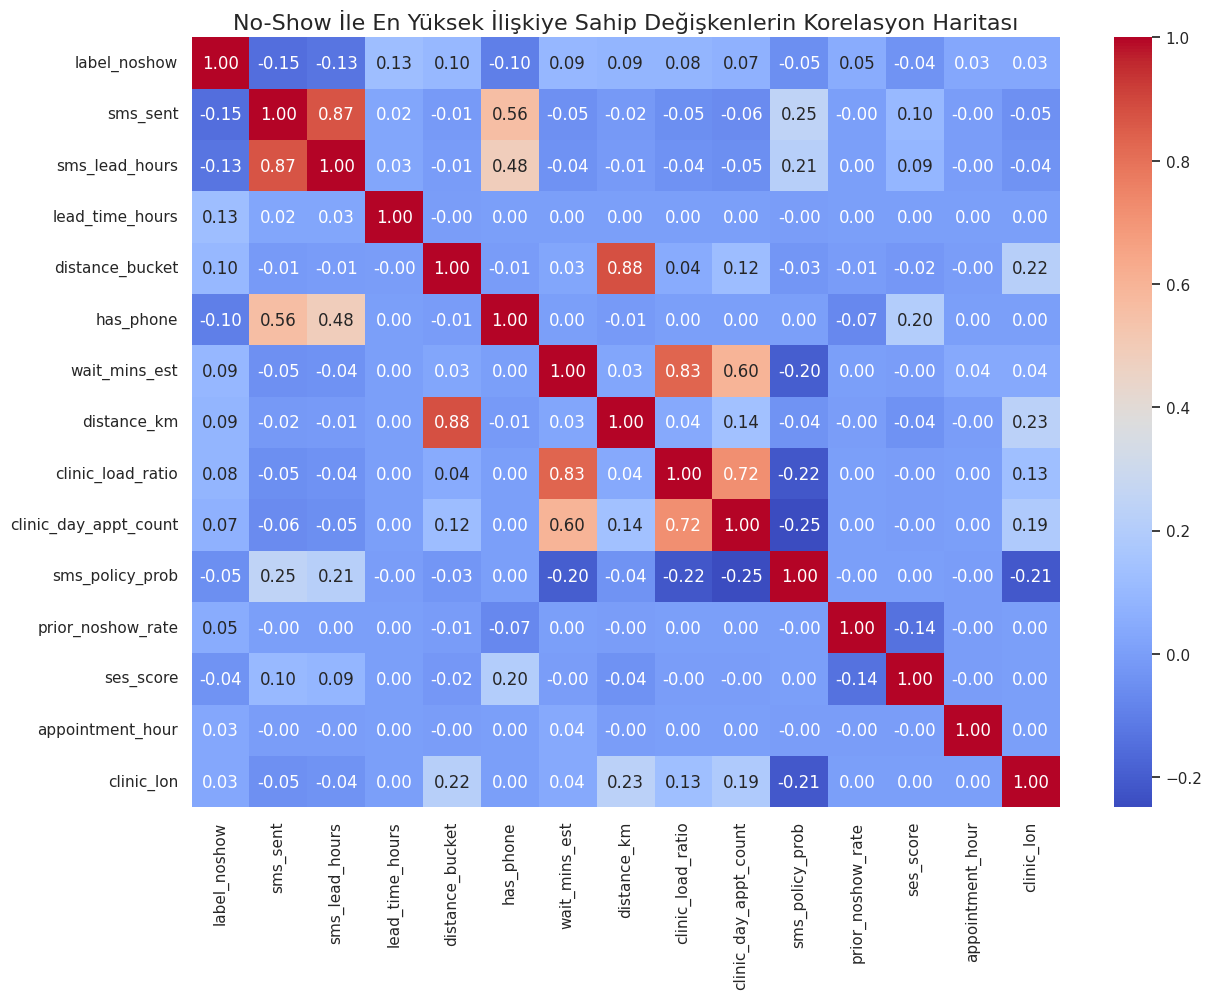

In [5]:
# Sadece sayısal (numeric) kolonları seçelim, çünkü metinlerle korelasyon hesaplanmaz
numeric_cols = df_final.select_dtypes(include=['int64', 'float64']).columns

# Korelasyon matrisini hesaplama
corr_matrix = df_final[numeric_cols].corr()

# No-show ile olan korelasyonları küçükten büyüğe sıralama
noshow_corr = corr_matrix['label_noshow'].sort_values(ascending=False)
print("--- Hedef Değişken (label_noshow) ile Korelasyonlar ---")
print(noshow_corr.head(10)) # En pozitif ilişkiler
print("...")
print(noshow_corr.tail(5))  # En negatif ilişkiler

# Isı haritası
top_features = noshow_corr.abs().sort_values(ascending=False).head(15).index
plt.figure(figsize=(14, 10))
sns.heatmap(df_final[top_features].corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("No-Show İle En Yüksek İlişkiye Sahip Değişkenlerin Korelasyon Haritası", fontsize=16)
plt.show()

/tmp/ipykernel_55/1436578841.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='appointment_dow', y='label_noshow', data=df_final, ax=axes[0], palette="viridis")
/tmp/ipykernel_55/1436578841.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label_noshow', y='lead_time_hours', data=df_final, ax=axes[1], palette="Set2")


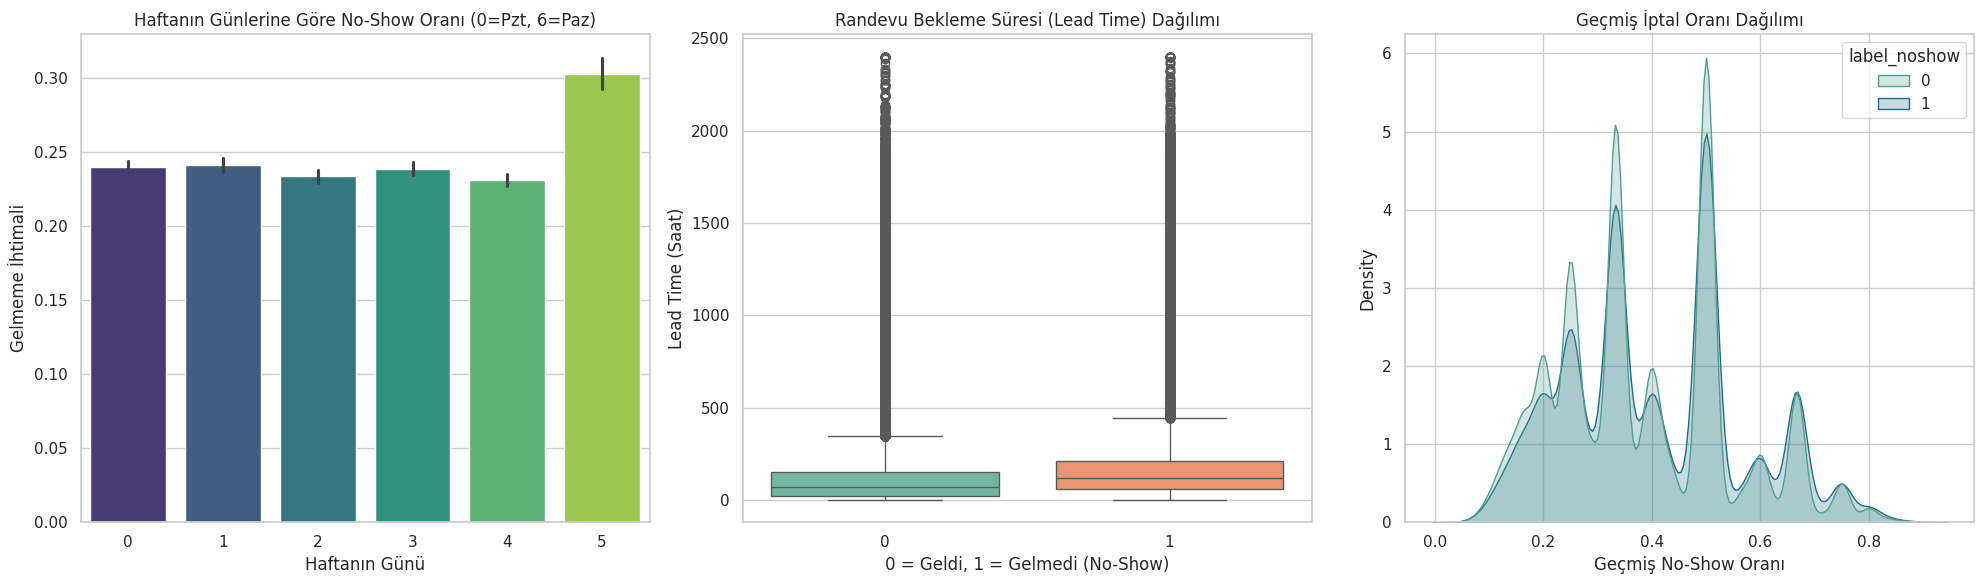

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# GRAFİK 1: Haftanın Günlerine Göre No-Show Oranı
# İnsanlar pazartesi sendromuyla mı randevuyu ekiyor, yoksa cuma rehavetiyle mi?
sns.barplot(x='appointment_dow', y='label_noshow', data=df_final, ax=axes[0], palette="viridis")
axes[0].set_title("Haftanın Günlerine Göre No-Show Oranı (0=Pzt, 6=Paz)")
axes[0].set_ylabel("Gelmeme İhtimali")
axes[0].set_xlabel("Haftanın Günü")

# GRAFİK 2: Randevu Alma Süresi (Lead Time) ve No-Show İlişkisi
# Bugün öğleden sonraya aldığım randevuya mı gitmem, yoksa 3 ay sonraya aldığıma mı?
# Aykırı değerleri basmak için logaritmik bir yaklaşım veya sadece yoğun olan kısmı görebiliriz.
sns.boxplot(x='label_noshow', y='lead_time_hours', data=df_final, ax=axes[1], palette="Set2")
axes[1].set_title("Randevu Bekleme Süresi (Lead Time) Dağılımı")
axes[1].set_xlabel("0 = Geldi, 1 = Gelmedi (No-Show)")
axes[1].set_ylabel("Lead Time (Saat)")

# GRAFİK 3: Hastanın Geçmiş İptal Oranı (Prior No-Show Rate)
# "Bir kere yapan hep yapar mı?" sorusunun cevabı.
sns.kdeplot(data=df_final, x='prior_noshow_rate', hue='label_noshow', fill=True, common_norm=False, ax=axes[2], palette="crest")
axes[2].set_title("Geçmiş İptal Oranı Dağılımı")
axes[2].set_xlabel("Geçmiş No-Show Oranı")

plt.tight_layout()
plt.show()

In [7]:
print("Şefin Mutfağına Hoş Geldiniz! Özellik Mühendisliği (Feature Engineering) Başlıyor...")

# Kopya üzerinde çalışalım ki orijinal verimiz bozulmasın
df_fe = df_final.copy()

# 1. ZAMANSAL ÖZELLİKLER (Datetime Parsing)
# Randevu tarihinden ay, gün, ve saati söküp alıyoruz.
df_fe['appt_month'] = df_fe['appointment_datetime'].dt.month
df_fe['appt_day'] = df_fe['appointment_datetime'].dt.day
# Hastanın randevu oluşturma saati (gece yarısı mı almış, öğlen mi?)
df_fe['booking_hour'] = df_fe['booking_datetime'].dt.hour

# Sabah, Öğle, Akşam kırılımı (0-1-2 gibi kategoriler yaratıyoruz)
df_fe['is_morning_appt'] = (df_fe['appointment_hour'] < 12).astype(int)
df_fe['is_afternoon_appt'] = ((df_fe['appointment_hour'] >= 12) & (df_fe['appointment_hour'] < 17)).astype(int)

# 2. HASTA DAVRANIŞI (Sabıka Kaydı ve Risk İndeksleri)
# Güvenilirlik Skoru: Geçmişte ne kadar güvenilirse puanı o kadar yüksek
df_fe['patient_reliability_score'] = 1.0 - df_fe['prior_noshow_rate']

# Unutkanlık Riski: Randevu alma süresi * Geçmiş İptal Oranı
# (Çok bekleyen bir sabıkalının riski tavan yapar!)
df_fe['risk_forgetfulness'] = df_fe['lead_time_hours'] * df_fe['prior_noshow_rate']

# 3. ZORLUK İNDEKSİ (Ulaşım ve Bekleme)
# Mesafe ile beklenen sürenin çarpımı (Kliniğe ulaşmak zor, bir de üstüne bekleyecek)
df_fe['friction_index'] = df_fe['distance_km'] * df_fe['wait_mins_est']

# 4. COLD-START İÇİN KLİNİK KARAKTERİ (Çok Önemli!)
# Kliniğin o günkü stres/kaos seviyesi
df_fe['clinic_stress_index'] = df_fe['clinic_load_ratio'] * df_fe['base_wait_mins_est']
# Klinik büyük mü küçük mü? (Kapasitesi yüksek kliniklerin dinamikleri farklıdır)
df_fe['is_large_clinic'] = (df_fe['capacity_daily'] > df_fe['capacity_daily'].median()).astype(int)

# 5. İLETİŞİM ETKİNLİĞİ
# Telefonu var ama SMS atılmamışsa bu bir operasyonel eksikliktir (Sistem Hatası Riski)
df_fe['missed_sms_opportunity'] = ((df_fe['has_phone'] == 1) & (df_fe['sms_sent'] == 0)).astype(int)

# Modelin kafasını karıştıracak, artık işi bitmiş "Datetime" kolonlarını siliyoruz
df_fe.drop(['appointment_datetime', 'booking_datetime'], axis=1, inplace=True)

print(f"Harika! Orijinal kolon sayımız 39'du. Şu anki kolon sayımız: {df_fe.shape[1]}")
print("İşte gerçek bir Senior Veri Seti! Modelimiz bu yeni soslara bayılacak.")

Şefin Mutfağına Hoş Geldiniz! Özellik Mühendisliği (Feature Engineering) Başlıyor...
Harika! Orijinal kolon sayımız 39'du. Şu anki kolon sayımız: 47
İşte gerçek bir Senior Veri Seti! Modelimiz bu yeni soslara bayılacak.


In [8]:
print("4. Adım: Zaman Bazlı Doğrulama (Time-Based Validation) Başlıyor...")

# 1. Ekim ayını (10. Ay) Validation (Doğrulama) Seti olarak ayırıyoruz.
# Diğer tüm geçmiş ayları (1'den 9'a kadar) Eğitim (Train) Seti yapıyoruz.
val_mask = df_fe['appt_month'] == 10

# 2. X (Özellikler) ve y (Hedef) ayrımı
# Hedef değişkenimiz olan 'label_noshow'u tablodan koparıyoruz.
# 'appointment_id', 'patient_id', 'clinic_id' kolonları da modelin ezber yapmasını (Leakage) engellemek için silinir. Onlar sadece birleştirme için lazımdı.
drop_cols = ['label_noshow', 'appointment_id', 'patient_id', 'clinic_id']

# Eğitim seti
X_train = df_fe[~val_mask].drop(columns=drop_cols)
y_train = df_fe[~val_mask]['label_noshow']

# Doğrulama (Validation) Seti
X_val = df_fe[val_mask].drop(columns=drop_cols)
y_val = df_fe[val_mask]['label_noshow']

print("Veri Seti Başarıyla Bölündü!")
print(f"X_train (Eğitim) Satır Sayısı: {X_train.shape[0]} (Bu satırlarla öğreneceğiz)")
print(f"X_val (Doğrulama) Satır Sayısı: {X_val.shape[0]} (Bu satırlarla kendimizi test edeceğiz)")

# Kategori tipindeki veriler (One-Hot Encoding yerine LightGBM/CatBoost'un native anlayacağı tipe çevirme) LightGBM gibi modeller metinleri sevmez, onlara "Bu kolon Kategorik!" dememiz lazım.
cat_cols = ['specialty', 'booking_channel', 'appointment_type', 'sex']
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')

print(f"Eğitim Seti Kolon Sayımız: {X_train.shape[1]}")

4. Adım: Zaman Bazlı Doğrulama (Time-Based Validation) Kurgusu Başlıyor...
Veri Seti Başarıyla Bölündü!
X_train (Eğitim) Satır Sayısı: 179080 (Bu satırlarla öğreneceğiz)
X_val (Doğrulama) Satır Sayısı: 20920 (Bu satırlarla kendimizi test edeceğiz)
Eğitim Seti Kolon Sayımız: 43


In [9]:
import lightgbm as lgb
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings('ignore')

print("5. Adım: İlk Modelin Eğitimi (Baseline LightGBM) Başlıyor...")

# 1. Veriyi LightGBM'in kendi özel ve hızlı formatına (Dataset) çeviriyoruz.
# Kategorik kolonları daha önce ayarladığımız için LighGBM bunları otomatik tanıyacak.
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# 2. Modelin Beynini (Hiperparametreleri) Ayarlıyoruz
params = {
    'objective': 'binary',             # İki sınıflı bir problem çözüyoruz (0 veya 1)
    'metric': 'average_precision',     # Kaggle'ın bizden istediği yarışma metriği (PR-AUC)
    'learning_rate': 0.05,             # Öğrenme hızı (Çok hızlı öğrenirse detayları kaçırır, 0.05 iyidir)
    'num_leaves': 31,                  # Ağacın yaprak sayısı (Karmaşıklık sınırı)
    'is_unbalance': True,              # Sınıf dengesizliğini (%76 - %24) modele bildiriyoruz
    'random_state': 42,
    'verbose': -1                      # Gereksiz uyarı mesajlarını kapatıyoruz
}

# 3. Eğitimi Başlatıyoruz
model_lgb = lgb.train(
    params,
    train_data,
    num_boost_round=1500, # Maksimum 1500 deneme turu hakkı veriyoruz
    valid_sets=[train_data, val_data],
    valid_names=['Eğitim (Train)', 'Doğrulama (Val)'],
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), # 50 tur boyunca PR-AUC artmazsa eğitimi kes!
        lgb.log_evaluation(50)                  # Her 50 turda bir durumu bize raporla
    ]
)

# 4. Ekim Ayı (Doğrulama Seti) Üzerinde Olasılık Tahminleri
# Model bize "Geldi" veya "Gelmedi" (0/1) demeyecek. Bize "Gelmemesine %85 ihtimal veriyorum" diyecek.
y_pred_probs = model_lgb.predict(X_val)

# 5. Gerçek Başarımızı (PR-AUC) Sklearn ile Hesaplıyoruz
pr_auc_score = average_precision_score(y_val, y_pred_probs)

print("\n" + "="*60)
print(f"🎉 Tiyatro Provası Bitti! Ekim Ayı PR-AUC Skorunuz: {pr_auc_score:.4f}")
print("="*60 + "\n")

5. Adım: İlk Modelin Eğitimi (Baseline LightGBM) Başlıyor...
Training until validation scores don't improve for 50 rounds
[50]	Eğitim (Train)'s average_precision: 0.49888	Doğrulama (Val)'s average_precision: 0.484997
[100]	Eğitim (Train)'s average_precision: 0.511884	Doğrulama (Val)'s average_precision: 0.491822
[150]	Eğitim (Train)'s average_precision: 0.51984	Doğrulama (Val)'s average_precision: 0.492033
Early stopping, best iteration is:
[133]	Eğitim (Train)'s average_precision: 0.517341	Doğrulama (Val)'s average_precision: 0.492278

🎉 Tiyatro Provası Bitti! Ekim Ayı PR-AUC Skorunuz: 0.4923



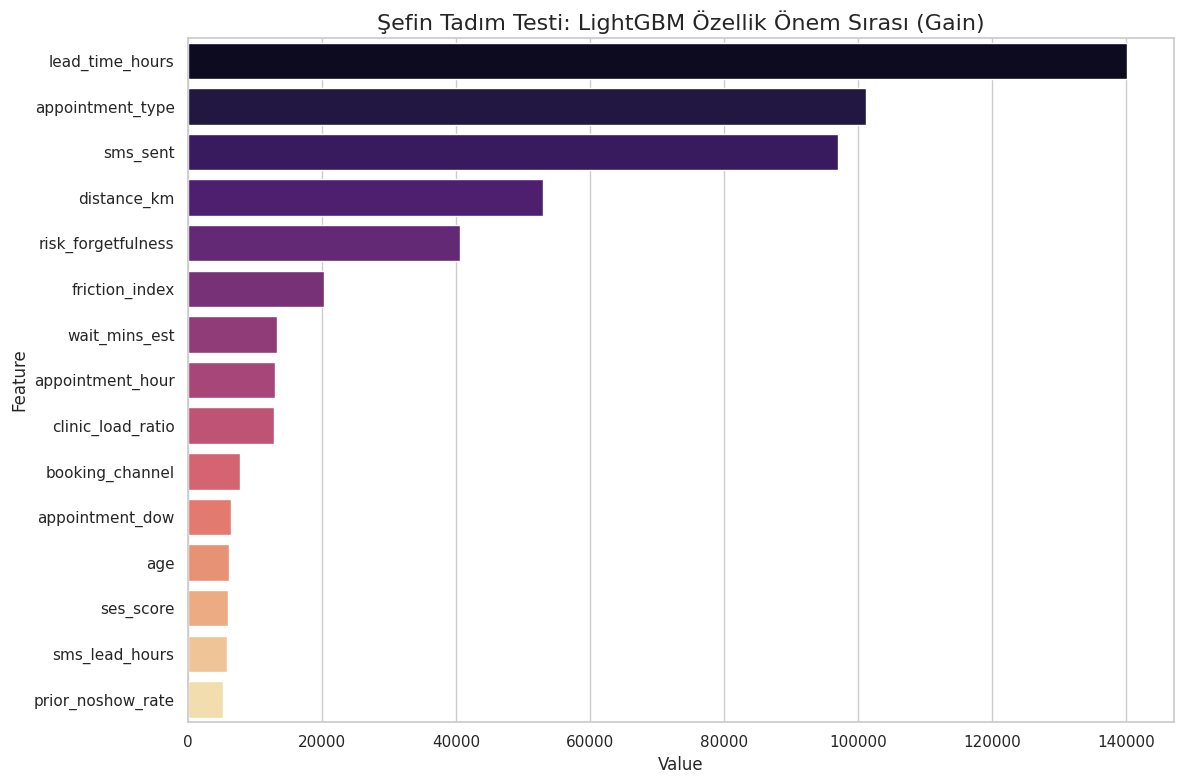

In [10]:
# Modelimizin karar mekanizmasında hangi değişkenlerin en yüksek "KAZANÇ" (Gain) sağladığını buluyoruz ve görselleştiriyoruz.
feature_imp = pd.DataFrame(sorted(zip(model_lgb.feature_importance(importance_type='gain'), X_train.columns)), columns=['Value','Feature'])

plt.figure(figsize=(12, 8))
# En önemli 15 özelliği çizdirelim
sns.barplot(x="Value", y="Feature", data=feature_imp.sort_values(by="Value", ascending=False).head(15), palette="magma")
plt.title('Şefin Tadım Testi: LightGBM Özellik Önem Sırası (Gain)', fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
import optuna
import lightgbm as lgb
from sklearn.metrics import average_precision_score
import warnings
warnings.filterwarnings('ignore')

print("6. Adım: Optuna ile Hiperparametre Optimizasyonu (Tuning) Başlıyor...")

def objective(trial):
    # Optuna'nın denemesini istediğimiz hiperparametre aralıkları
    params = {
        'objective': 'binary',
        'metric': 'average_precision',
        'is_unbalance': True,
        'verbosity': -1,
        'boosting_type': 'gbdt',
        'random_state': 42,
        # Öğrenme Hızı: Çok hızlı öğrenirse ezberler, çok yavaş öğrenirse vaktimiz yetmez
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        # Yaprak Sayısı: Modelin ne kadar karmaşık düşünebileceği (Aşırı artarsa ezberler)
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        # Ağaç Derinliği
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        # Aşırı öğrenmeyi engellemek için rassallık katalım (Verinin ve kolonların belli bir kısmını kullan)
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        # Bir yaprakta bulunması gereken minimum veri (Outlier'lardan etkilenmemek için)
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100)
    }

    # Veri setleri
    train_data = lgb.Dataset(X_train, label=y_train)
    val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

    # Modeli bu ayarlar ile eğitiyoruz
    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[val_data],
        callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)] 
    )

    # Validation seti üzerinde tahmin yapıp skoru hesaplıyoruz
    preds = model.predict(X_val)
    score = average_precision_score(y_val, preds)
    
    return score # Optuna bu skoru MAKSİMİZE etmeye çalışacak

# Optuna çalışmasını başlatıyoruz (direction='maximize' çünkü PR-AUC ne kadar yüksek o kadar iyi)
study = optuna.create_study(direction='maximize', study_name="LightGBM_Optimization")
# Zaman kazanmak adına 30 farklı kombinasyon (trial) deneteceğiz
study.optimize(objective, n_trials=30)

print("\n" + "="*60)
print(f"🏆 Optuna Araması Bitti!")
print(f"Elde Edilen EN İYİ PR-AUC Skoru: {study.best_value:.4f}")
print("En İyi Hiperparametreler:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")
print("="*60 + "\n")

[I 2026-03-16 12:57:51,232] A new study created in memory with name: LightGBM_Optimization


6. Adım: Optuna ile Hiperparametre Optimizasyonu (Tuning) Başlıyor...


[I 2026-03-16 12:57:54,712] Trial 0 finished with value: 0.4930246643041629 and parameters: {'learning_rate': 0.045128819495070166, 'num_leaves': 30, 'max_depth': 4, 'subsample': 0.7351819645454007, 'colsample_bytree': 0.6449795396096112, 'min_child_samples': 78}. Best is trial 0 with value: 0.4930246643041629.
[I 2026-03-16 12:57:56,835] Trial 1 finished with value: 0.4900077679933832 and parameters: {'learning_rate': 0.09357803382576332, 'num_leaves': 69, 'max_depth': 6, 'subsample': 0.733974238110354, 'colsample_bytree': 0.892114891463524, 'min_child_samples': 20}. Best is trial 0 with value: 0.4930246643041629.
[I 2026-03-16 12:57:59,701] Trial 2 finished with value: 0.4924888469853554 and parameters: {'learning_rate': 0.053644126864429396, 'num_leaves': 42, 'max_depth': 8, 'subsample': 0.9639410626683432, 'colsample_bytree': 0.7731348505659199, 'min_child_samples': 65}. Best is trial 0 with value: 0.4930246643041629.
[I 2026-03-16 12:58:04,279] Trial 3 finished with value: 0.49031


🏆 Optuna Araması Bitti!
Elde Edilen EN İYİ PR-AUC Skoru: 0.4940
En İyi Hiperparametreler:
  learning_rate: 0.0212949958375123
  num_leaves: 65
  max_depth: 4
  subsample: 0.8239445910695335
  colsample_bytree: 0.90180365109014
  min_child_samples: 74



In [12]:
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score
import pandas as pd

print("7. Adım: Uzmanlar Konseyi (Ensemble) Kuruluyor...")

# 1. LightGBM (Optuna'nın bulduğu Altın Parametreler ile)
lgb_params = {
    'objective': 'binary',
    'metric': 'average_precision',
    'is_unbalance': True,
    'learning_rate': 0.0213,
    'num_leaves': 65,
    'max_depth': 4,
    'subsample': 0.824,
    'colsample_bytree': 0.902,
    'min_child_samples': 74,
    'verbosity': -1,
    'random_state': 42
}
train_data_lgb = lgb.Dataset(X_train, label=y_train)
print("-> LightGBM Eğitiliyor...")
model_lgb = lgb.train(lgb_params, train_data_lgb, num_boost_round=800)
preds_lgb = model_lgb.predict(X_val)

# 2. CatBoost
# Kategorik kolonların isimlerini listeliyoruz
cat_features_list = ['specialty', 'booking_channel', 'appointment_type', 'sex']
print("-> CatBoost Eğitiliyor...")
model_cat = CatBoostClassifier(
    iterations=800,
    learning_rate=0.03,
    depth=5,
    auto_class_weights='Balanced', # Sınıf dengesizliğini çözmek için
    cat_features=cat_features_list,
    eval_metric='AUC', # CatBoost native PR-AUC desteklemediği için AUC kullanıp optimize ediyoruz
    random_seed=42,
    verbose=0
)
model_cat.fit(X_train, y_train, cat_features=cat_features_list)
preds_cat = model_cat.predict_proba(X_val)[:, 1]

# 3. XGBoost
print("-> XGBoost Eğitiliyor...")
# XGBoost Pandas 'category' tipini doğrudan destekler (enable_categorical=True ile)
model_xgb = xgb.XGBClassifier(
    n_estimators=800,
    learning_rate=0.02,
    max_depth=5,
    scale_pos_weight=3, # Sınıf dengesizliği için ( %76 / %24 yaklaşık 3 katı)
    enable_categorical=True,
    tree_method='hist',
    random_state=42,
    eval_metric='aucpr' # XGBoost PR-AUC (aucpr) destekler!
)
model_xgb.fit(X_train, y_train)
preds_xgb = model_xgb.predict_proba(X_val)[:, 1]

# 4. Harmanlama (Blending)
# Ağırlıkları şimdilik eşit veya LightGBM'e biraz torpil geçerek dağıtalım:
# %40 LightGBM, %30 CatBoost, %30 XGBoost
final_val_preds = (0.40 * preds_lgb) + (0.30 * preds_cat) + (0.30 * preds_xgb)

# 5. Yeni ve Nihai Skoru Hesaplama
ensemble_pr_auc = average_precision_score(y_val, final_val_preds)

print("\n" + "="*60)
print(f"🚀 Uzmanlar Konseyi Kararı (Ensemble) Bitti!")
print(f"LGBM Tek Başına Skor: {average_precision_score(y_val, preds_lgb):.4f}")
print(f"Nihai ENSEMBLE PR-AUC Skorumuz: {ensemble_pr_auc:.5f}")
print("="*60 + "\n")

7. Adım: Uzmanlar Konseyi (Ensemble) Kuruluyor...
-> LightGBM Eğitiliyor...
-> CatBoost Eğitiliyor...
-> XGBoost Eğitiliyor...

🚀 Uzmanlar Konseyi Kararı (Ensemble) Bitti!
LGBM Tek Başına Skor: 0.4934
Nihai ENSEMBLE PR-AUC Skorumuz: 0.49391



In [14]:
print("8. Adım: Gerçek Sınav! Test Seti Hazırlanıyor ve Tahminler Üretiliyor...")

# 1. Test Verilerini Okuma ve Birleştirme
test_df = pd.read_csv('/kaggle/input/competitions/data-league26/appointments_test.csv')
# patients_df ve clinics_df zaten hafızada var, onları kullanarak birleştiriyoruz
df_test_merged = test_df.merge(patients_df, on='patient_id', how='left')
df_test_final = df_test_merged.merge(clinics_df, on='clinic_id', how='left')

# 2. Birebir Aynı Temizlik ve Özellik Mühendisliği (Feature Engineering)
df_test_final.drop(columns=['specialty_y'], inplace=True, errors='ignore')
df_test_final.rename(columns={'specialty_x': 'specialty'}, inplace=True)

df_test_final['appointment_datetime'] = pd.to_datetime(df_test_final['appointment_datetime'])
df_test_final['booking_datetime'] = pd.to_datetime(df_test_final['booking_datetime'])
df_test_final['sms_lead_hours'] = df_test_final['sms_lead_hours'].fillna(-999)

# Zamansal
df_test_final['appt_month'] = df_test_final['appointment_datetime'].dt.month
df_test_final['appt_day'] = df_test_final['appointment_datetime'].dt.day
df_test_final['booking_hour'] = df_test_final['booking_datetime'].dt.hour
df_test_final['is_morning_appt'] = (df_test_final['appointment_hour'] < 12).astype(int)
df_test_final['is_afternoon_appt'] = ((df_test_final['appointment_hour'] >= 12) & (df_test_final['appointment_hour'] < 17)).astype(int)

# Hasta ve Zorluk
df_test_final['patient_reliability_score'] = 1.0 - df_test_final['prior_noshow_rate']
df_test_final['risk_forgetfulness'] = df_test_final['lead_time_hours'] * df_test_final['prior_noshow_rate']
df_test_final['friction_index'] = df_test_final['distance_km'] * df_test_final['wait_mins_est']

# Klinik Stresi
df_test_final['clinic_stress_index'] = df_test_final['clinic_load_ratio'] * df_test_final['base_wait_mins_est']

# DİKKAT: is_large_clinic için eğitim setindeki medyan kapasiteyi kullanmalıyız (Data Leakage olmasın diye)
# Biz eğitim setinde median() hesaplamıştık, kabaca o değeri kullanalım. (Kodun önceki kısmında hesaplandığı için)
train_median_capacity = df_final['capacity_daily'].median()
df_test_final['is_large_clinic'] = (df_test_final['capacity_daily'] > train_median_capacity).astype(int)

df_test_final['missed_sms_opportunity'] = ((df_test_final['has_phone'] == 1) & (df_test_final['sms_sent'] == 0)).astype(int)

# 3. Modele Girecek Formata Getirme
df_test_final.drop(['appointment_datetime', 'booking_datetime'], axis=1, inplace=True)

# Test setindeki randevu ID'lerini Kaggle dosyası için güvenli bir yere kopyalayalım
submission_ids = df_test_final['appointment_id']

# Tahmin aşamasında modele ID'leri vermiyoruz
drop_cols_test = ['appointment_id', 'patient_id', 'clinic_id']
# Test setinde 'label_noshow' zaten yok, o yüzden onu silmeye çalışmıyoruz
X_test = df_test_final.drop(columns=drop_cols_test)

# Kategorik kolon ayarı
for col in cat_cols:
    X_test[col] = X_test[col].astype('category')

# 4. TAHMİN VAKTİ
print("-> LightGBM Tahmin Ediyor...")
preds_test_lgb = model_lgb.predict(X_test)

print("-> CatBoost Tahmin Ediyor...")
preds_test_cat = model_cat.predict_proba(X_test)[:, 1]

print("-> XGBoost Tahmin Ediyor...")
# XGBoost bazen kolon sırası bozulursa hata verebilir, o yüzden X_train ile aynı sırada olduğundan emin olalım
X_test = X_test[X_train.columns] 
preds_test_xgb = model_xgb.predict_proba(X_test)[:, 1]

# 5. HARMANLAMA (Blending) - Aynı ağırlıklarla
final_test_preds = (0.40 * preds_test_lgb) + (0.30 * preds_test_cat) + (0.30 * preds_test_xgb)

# 6. Kaggle Submission Dosyasını Oluşturma
submission = pd.DataFrame({
    'appointment_id': submission_ids,
    'label_noshow': final_test_preds
})

submission.to_csv('submission_senior_ensemble.csv', index=False)
print("\n" + "="*60)
print(f"🎉 HARİKA! 'submission_senior_ensemble.csv' dosyası başarıyla oluşturuldu.")
print("="*60 + "\n")

8. Adım: Gerçek Sınav! Test Seti Hazırlanıyor ve Tahminler Üretiliyor...
-> LightGBM Tahmin Ediyor...
-> CatBoost Tahmin Ediyor...
-> XGBoost Tahmin Ediyor...

🎉 HARİKA! 'submission_senior_ensemble.csv' dosyası başarıyla oluşturuldu.
Bu dosyayı Kaggle'a yükle ve o Leaderboard'daki gerçek yerimizi görelim!

